# OMA Heatmap: Avvikelse per person och fas

**Using IRAF score for different positions Rak and Kors**

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

INPUT_RAK  = Path('../data/processed/OMA_Score/OMA_Phase_Score_Rak.csv')
INPUT_KORS = Path('../data/processed/OMA_Score/OMA_Phase_Score_Kors.csv')
OUT_DIR    = Path('../data/processed/OMA_Score')

df_rak  = pd.read_csv(INPUT_RAK)
df_kors = pd.read_csv(INPUT_KORS)
print(f'Rak:  {len(df_rak)} rader')
print(f'Kors: {len(df_kors)} rader')

Rak:  30 rader
Kors: 30 rader


In [ ]:
PHASE_LABELS = {
                'f1': 'Utgångsposition',
                'f2': 'Rörelsestart', 
                'f3': 'Rörelseutförande'
                }

PERSON_LABELS = {
                'fp1': 'P1', 
                'fp2': 'P2',
                'fp3': 'P3',
                'fp4': 'P4', 
                'fp5': 'P5'
                }

MOVEMENT_LABELS = {
                   '2a_1': 'Sit-to-stand', 
                   '2a_2': 'Stand-to-sit'
                   }


def build_pivot(df, rorelse_id):
    sub = df[df['RörelseId'] == rorelse_id]
    pivot = sub.pivot(index='PersonId', columns='PhaseId', values='Avg_Gem_Avvikelse')
    pivot = pivot.reindex(index=list(PERSON_LABELS), columns=['f1', 'f2', 'f3'])
    pivot.index = [PERSON_LABELS[p] for p in pivot.index]
    pivot.columns = [PHASE_LABELS[c] for c in pivot.columns]
    pivot.index.name = 'Person'
    pivot.columns.name = None
    return pivot.round(2)


pivots = {}
for cond, df in [('Rak', df_rak), ('Kors', df_kors)]:
    for rid in ['2a_1', '2a_2']:
        pivots[(cond, rid)] = build_pivot(df, rid)

for cond in ['Rak', 'Kors']:
    for rid, mov in MOVEMENT_LABELS.items():
        print(f'{cond} - {mov}')
        display(pivots[(cond, rid)])
        print()

Rak - Sit-to-stand


,Utgångsposition,Rörelsestart,Rörelseutförande
Person,,,
P1,0.11,0.0,0.0
P2,0.70,0.0,0.4
P3,0.33,0.0,0.1
P4,0.10,0.0,0.5
P5,0.44,1.0,0.3



Rak - Stand-to-sit


,Utgångsposition,Rörelsestart,Rörelseutförande
Person,,,
P1,0.0,0.0,0.29
P2,0.5,0.0,0.43
P3,0.2,0.0,0.14
P4,0.6,1.0,0.57
P5,0.9,0.0,0.43



Kors - Sit-to-stand


,Utgångsposition,Rörelsestart,Rörelseutförande
Person,,,
P1,1.1,2.0,0.8
P2,1.2,2.0,1.0
P3,1.3,2.0,1.0
P4,1.3,2.0,1.0
P5,1.5,1.0,0.8



Kors - Stand-to-sit


,Utgångsposition,Rörelsestart,Rörelseutförande
Person,,,
P1,0.50,0.0,0.29
P2,1.08,1.0,0.71
P3,0.44,0.0,0.29
P4,0.91,1.0,0.57
P5,0.92,0.0,0.57


In [32]:
def plot_heatmap(pivot, title, ax, vmin=0, vmax=2):
    data = pivot.values.astype(float)
    cmap = plt.cm.RdYlGn_r

    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, fontsize=11)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=11)

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=12, fontweight='bold', color='black')

    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Fas', fontsize=11)
    ax.set_ylabel('Person', fontsize=11)
    return im

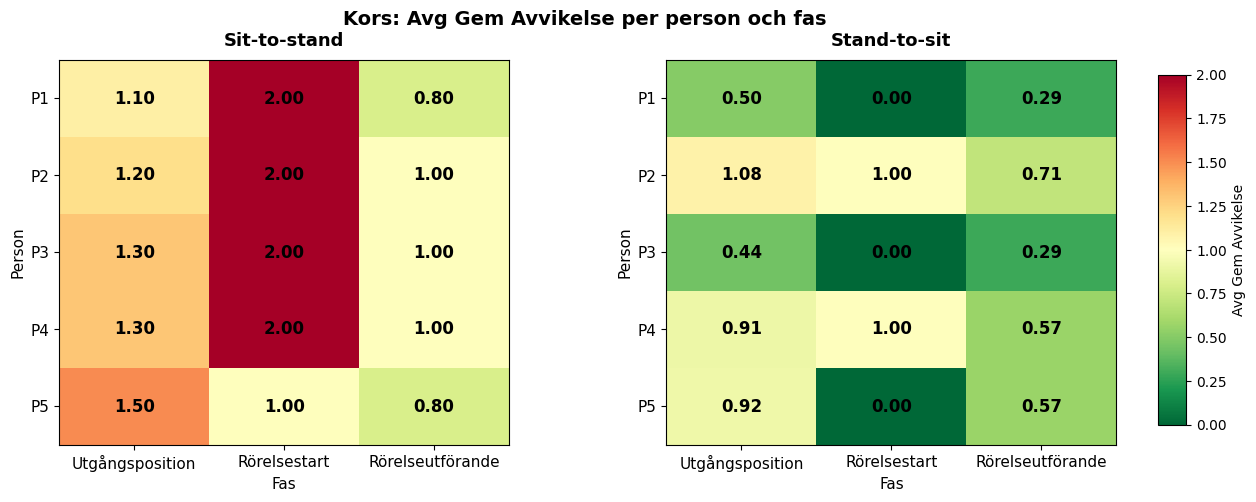

Sparad: ../data/processed/OMA_Score/heatmap_avvikelse_kors.png


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Kors: Avg Gem Avvikelse per person och fas', fontsize=14, fontweight='bold')
im1 = plot_heatmap(pivots[('Kors', '2a_1')], 'Sit-to-stand', axes[0])
im2 = plot_heatmap(pivots[('Kors', '2a_2')], 'Stand-to-sit', axes[1])
fig.subplots_adjust(right=0.88, wspace=0.35)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
fig.colorbar(im1, cax=cbar_ax, label='Avg Gem Avvikelse')
out = OUT_DIR / 'heatmap_avvikelse_kors.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Sparad: {out}')

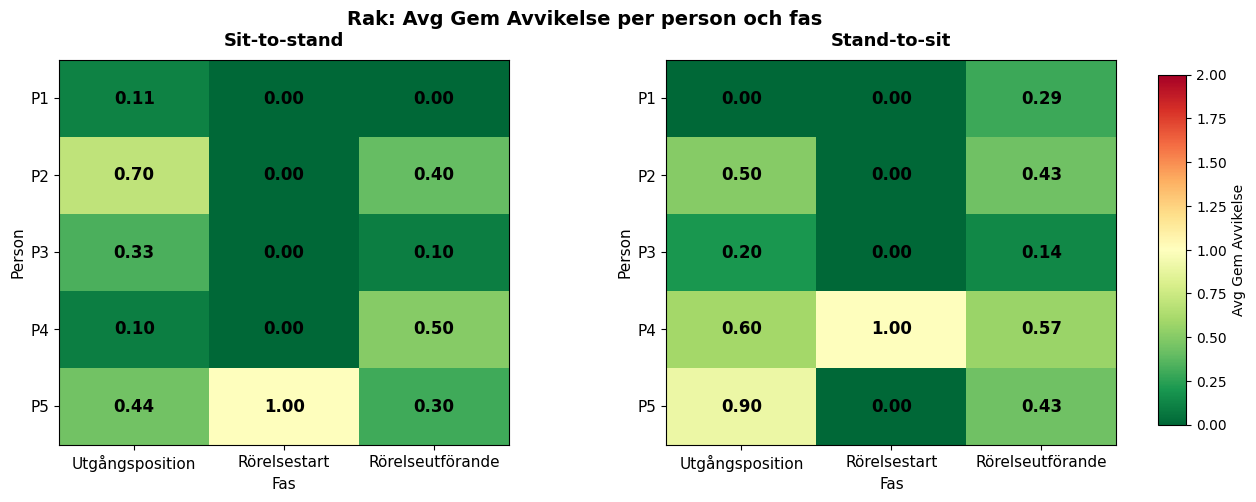

Sparad: ../data/processed/OMA_Score/heatmap_avvikelse_rak.png


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Rak: Avg Gem Avvikelse per person och fas', fontsize=14, fontweight='bold')
im1 = plot_heatmap(pivots[('Rak', '2a_1')], 'Sit-to-stand', axes[0])
im2 = plot_heatmap(pivots[('Rak', '2a_2')], 'Stand-to-sit', axes[1])
fig.subplots_adjust(right=0.88, wspace=0.35)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
fig.colorbar(im1, cax=cbar_ax, label='Avg Gem Avvikelse')
out = OUT_DIR / 'heatmap_avvikelse_rak.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Sparad: {out}')

There is a clear difference between the **Rak** and **Kors** conditions. Using *Kors* arms makes it harder to analyze movement, especially for sit-to-stand tasks. Interestingly, **stand-to-sit** performs better than **sit-to-stand** in the *Kors* condition, which suggests that **the type of movement can influence pose estimation performance as much as the position of the arms**.